In [2]:
pip install numpy pandas matplotlib seaborn scikit-learn jupyter

Note: you may need to restart the kernel to use updated packages.


   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
Accuracy: 0.8100558659217877


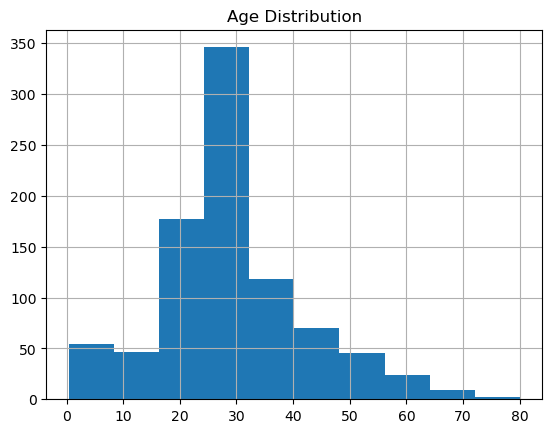

In [3]:
# =========================
# IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# =========================
# LOAD DATA
# =========================
df = sns.load_dataset("titanic")

print(df.head())

# =========================
# DATA CLEANING
# =========================

# Fill missing values
df['age'].fillna(df['age'].mean(), inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

# Drop unnecessary columns
df = df.drop(['deck', 'embark_town', 'alive'], axis=1)

# Convert categorical to numeric
df = pd.get_dummies(df, drop_first=True)

# =========================
# TRAIN MODEL
# =========================
X = df.drop('survived', axis=1)
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# =========================
# EVALUATION
# =========================
accuracy = model.score(X_test, y_test)
print("Accuracy:", accuracy)

# =========================
# VISUALIZATION
# =========================
df['age'].hist()
plt.title("Age Distribution")
plt.show()

In [4]:
import pandas as pd
import seaborn as sns

df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [7]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [4]:
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

In [5]:
df = sns.load_dataset("titanic")

In [6]:
df['age'].fillna(df['age'].mean(), inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

df = df.drop(['deck', 'embark_town', 'alive'], axis=1)

df = pd.get_dummies(df, drop_first=True)

In [7]:
X = df.drop('survived', axis=1)
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [8]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [9]:
y_pred = model.predict(X_test)

In [10]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Confusion Matrix:
 [[102  15]
 [ 16  46]]

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.87      0.87       117
           1       0.75      0.74      0.75        62

    accuracy                           0.83       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.83      0.83      0.83       179



In [2]:
import pandas as pd
import seaborn as sns

df = sns.load_dataset("titanic")

In [3]:

df['age'].fillna(df['age'].mean(), inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

df = df.drop(['deck', 'embark_town', 'alive'], axis=1)

In [4]:
df['family_size'] = df['sibsp'] + df['parch']
df['is_alone'] = (df['family_size'] == 0).astype(int)

In [5]:
df = pd.get_dummies(df, drop_first=True)

In [6]:
from sklearn.model_selection import train_test_split

X = df.drop('survived', axis=1)
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [7]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [8]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [9]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [10]:
print("Logistic:", lr.score(X_test, y_test))
print("Decision Tree:", dt.score(X_test, y_test))
print("Random Forest:", rf.score(X_test, y_test))

Logistic: 0.7877094972067039
Decision Tree: 0.6983240223463687
Random Forest: 0.7988826815642458


In [11]:
from sklearn.metrics import classification_report

y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.84      0.84       115
           1       0.72      0.72      0.72        64

    accuracy                           0.80       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.80      0.80      0.80       179



In [14]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

rf.fit(X_train, y_train)

print("Accuracy:", rf.score(X_test, y_test))

Accuracy: 0.8156424581005587


In [15]:
train_acc = rf.score(X_train, y_train)
test_acc = rf.score(X_test, y_test)

print("Train:", train_acc)
print("Test:", test_acc)

Train: 0.8455056179775281
Test: 0.8156424581005587


In [16]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5)

print("Cross-validation scores:", scores)
print("Average:", scores.mean())

Cross-validation scores: [0.84357542 0.81460674 0.8258427  0.80337079 0.84269663]
Average: 0.8260184545853996


In [17]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Params: {'max_depth': 10, 'n_estimators': 200}
Best Score: 0.8356794194471037


In [18]:
best_model = grid.best_estimator_

print("Final Accuracy:", best_model.score(X_test, y_test))

Final Accuracy: 0.7988826815642458


In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

print("Accuracy:", model.score(X_test_scaled, y_test))

Accuracy: 0.7932960893854749


In [21]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)

print("Accuracy:", pipeline.score(X_test, y_test))

Accuracy: 0.7932960893854749


In [22]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__C': [0.1, 1, 10]
}

grid = GridSearchCV(pipeline, param_grid, cv=3)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'model__C': 0.1}
